# 04. Modelización avanzada y validación temporal

Amplío las logísticas y uso ingenieria de variables. 

- **margen lineal:** `LinearSVC` calibrada
- **margen no lineal:** `SVC` con kernel RBF calibrada
- **bagging:** Random Forest con muestras *bootstrap*
- **boosting nativo:** HistGradientBoosting
- **boosting avanzado:** XGBoost
- **ensemble heterogéneo:** combinación probabilística aprendida fuera de muestra

Los hiperparámetros se eligen con validación temporal dentro de 2019–2023, 2024 actúa como validación externa y **2025 permanece sellado** para una única evaluación final.

In [1]:
from pathlib import Path
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import LinearSVC, SVC

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "Falta XGBoost. Desde la raíz del proyecto ejecuta: "
        "python -m pip install -r requirements.txt"
    ) from exc

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from tfm_accidentes.config import PROCESSED_DATA_DIR
from tfm_accidentes.data import read_analysis_table
from tfm_accidentes.features import add_advanced_features
from tfm_accidentes.model_selection import (
    ExpandingYearSplit,
    binary_classification_metrics,
    optimize_blend_weight,
    paired_bootstrap_pr_auc_difference,
    select_threshold_for_recall,
)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
warnings.filterwarnings('ignore', category=FutureWarning)

## 1. Muestra analítica e ingeniería de variables

Además de las codificaciones cíclicas, se crean variables disponibles en el momento del accidente:

- edad aproximada a partir del intervalo publicado y un indicador separado de edad desconocida;
- agrupación funcional del vehículo;
- usuario vulnerable (peatón, motocicleta, bicicleta o movilidad personal);
- meteorología adversa;
- interacciones persona–accidente y usuario–meteorología.

No se utilizan alcohol, drogas, lesividad, identificadores ni variables posteriores al resultado (el tipo de accidente es en el momento del accidente, así que lo incluyo porque los servicios de emergencia lo sabrán). Las interacciones son explícitas para que la logística pueda capturarlas, los árboles también pueden descubrir interacciones adicionales.

In [2]:
data_path = PROCESSED_DATA_DIR / 'accidentes_madrid_2019_2025.csv.gz'
data = read_analysis_table(data_path)
data = data.loc[data['lesion_grave'].notna()].copy()
data['lesion_grave'] = data['lesion_grave'].astype('int8')
data = add_advanced_features(data)

development = data.loc[data['anio'].between(2019, 2023)].copy()
validation = data.loc[data['anio'].eq(2024)].copy()
sealed_test = data.loc[data['anio'].eq(2025)].copy()  # No se generan predicciones.

split_summary = pd.DataFrame({
    'periodo': ['Desarrollo 2019-2023', 'Validación externa 2024', 'Test sellado 2025'],
    'filas': [len(development), len(validation), len(sealed_test)],
    'positivos': [development.lesion_grave.sum(), validation.lesion_grave.sum(), sealed_test.lesion_grave.sum()],
    'prevalencia': [development.lesion_grave.mean(), validation.lesion_grave.mean(), sealed_test.lesion_grave.mean()],
})
display(split_summary.assign(prevalencia=split_summary.prevalencia.map('{:.2%}'.format)))
assert development.anio.max() < validation.anio.min() < sealed_test.anio.min()

,periodo,filas,positivos,prevalencia
0,Desarrollo 2019-2023,221899,2706,1.22%
1,Validación externa 2024,49338,597,1.21%
2,Test sellado 2025,51067,493,0.97%


In [3]:
basic_categorical_features = ['distrito', 'tipo_accidente', 'estado_meteorologico', 'tipo_vehiculo',
    'tipo_persona', 'rango_edad', 'sexo',]


basic_numeric_features = ['hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'mes_sin', 'mes_cos','es_fin_semana', 'es_noche',]


base_categorical_features = [
    'distrito', 'tipo_accidente', 'estado_meteorologico', 'tipo_vehiculo','tipo_persona', 'rango_edad', 'sexo', 'grupo_vehiculo',
    'contexto_persona_accidente', 'contexto_usuario_entorno',]
numeric_features = ['hora_dia', 'dia_semana', 'mes', 'es_fin_semana', 'es_noche',
    'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'mes_sin', 'mes_cos',
    'edad_aproximada', 'edad_desconocida', 'usuario_vulnerable',
    'meteorologia_adversa',
]


all_features = base_categorical_features + numeric_features
target = 'lesion_grave'

X_development = development[all_features]
y_development = development[target]

development_years = development['anio'].to_numpy()

X_validation = validation[all_features]
y_validation = validation[target]

print(f'{len(all_features)} variables de entrada: 'f'{len(base_categorical_features)} categóricas y {len(numeric_features)} numéricas.')


25 variables de entrada: 10 categóricas y 15 numéricas.


## 2. Pipelines y familias de modelos

Cada transformación se ajusta dentro de un `Pipeline`, evitando que medianas, escalas o categorías futuras entren en el entrenamiento.

- **Regresión logística básica:** reproduce el baseline del notebook 03.
- **Regresión logística avanzada:** mide el valor añadido del *feature engineering* manteniendo el algoritmo.
- **LinearSVC calibrada:** cambia la log-loss por una función de margen. La calibración sigmoide aporta probabilidades comparables, aunque aumenta el coste.
- **SVC RBF calibrada:** introduce una frontera no lineal mediante un kernel radial exacto.
- **Random Forest:** bagging explícito, cada árbol se ajusta sobre una muestra bootstrap y se promedian probabilidades.
- **HistGradientBoosting:** árboles secuenciales sobre variables discretizadas en histogramas, con soporte categórico.
- **XGBoost:** boosting regularizado con submuestreo de filas/columnas y control específico del peso positivo.

Para la `SVC` RBF se utiliza una única configuración controlada (`C=1`, `gamma='scale'`) y no una búsqueda exhaustiva, porque su coste crece al menos cuadráticamente con el número de observaciones. Se calibra mediante una sigmoide para integrarla en las comparaciones probabilísticas del notebook.

In [4]:
def selected_categorical_features(include_sex=True):
    return [c for c in base_categorical_features if include_sex or c != 'sexo'] #esto para luego ver si merece la pena incluir el sexo



def make_one_hot_preprocessor(include_sex=True, drop=None):
    categorical = selected_categorical_features(include_sex)
    return ColumnTransformer([
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='No consta')),
            ('encoder', OneHotEncoder(
                handle_unknown='infrequent_if_exist', min_frequency=100,
                drop=drop, sparse_output=True,)),]), categorical),
        
        ('numeric', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), numeric_features),])


def make_ordinal_preprocessor(include_sex=True):
    categorical = selected_categorical_features(include_sex)
    return ColumnTransformer([
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='No consta')),
            ('encoder', OrdinalEncoder(
                handle_unknown='use_encoded_value', unknown_value=-1,
                encoded_missing_value=-1,)),
        ]), categorical),
        ('numeric', SimpleImputer(strategy='median'), numeric_features),])


def make_logistic(include_sex=True):
    return Pipeline([
        ('preprocessor', make_one_hot_preprocessor(include_sex, drop='first')),
        ('model', LogisticRegression(max_iter=1500, solver='lbfgs', random_state=RANDOM_STATE)),
    ])


def make_basic_logistic():
    preprocessor = ColumnTransformer([
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='No consta')),
            ('encoder', OneHotEncoder(
                handle_unknown='infrequent_if_exist', min_frequency=100,
                drop='first', sparse_output=True,)),
        ]), basic_categorical_features),
        
        ('numeric', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), basic_numeric_features),])
    return Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1500, solver='lbfgs', random_state=RANDOM_STATE)),])


def make_linear_svm(params, include_sex=True):
    svm_pipeline = Pipeline([
        ('preprocessor', make_one_hot_preprocessor(include_sex, drop='first')),
        ('model', LinearSVC(
            dual='auto', max_iter=5000, random_state=RANDOM_STATE, **params
        )),])
    
    return CalibratedClassifierCV(estimator=svm_pipeline, method='sigmoid', cv=3, ensemble=False)


def make_rbf_svm(include_sex=True):
    rbf_pipeline = Pipeline([
        ('preprocessor', make_one_hot_preprocessor(
            include_sex,
            drop=None,
        )),
        ('model', SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            class_weight=None,
            probability=False,
            cache_size=2000,)),])
    return CalibratedClassifierCV(estimator=rbf_pipeline, method='sigmoid', cv=2, ensemble=True, n_jobs=None, )

def make_random_forest(params, include_sex=True):
    return Pipeline([
        ('preprocessor', make_one_hot_preprocessor(include_sex, drop=None)),
        ('model', RandomForestClassifier(
            bootstrap=True, n_jobs=-1, random_state=RANDOM_STATE, **params)),])




def make_hist_gradient_boosting(params, include_sex=True):
    categorical = selected_categorical_features(include_sex)
    return Pipeline([
        ('preprocessor', make_ordinal_preprocessor(include_sex)),
        ('model', HistGradientBoostingClassifier(
            categorical_features=list(range(len(categorical))),
            early_stopping=False, random_state=RANDOM_STATE, **params)),])


def make_xgboost(params, include_sex=True):
    return Pipeline([
        ('preprocessor', make_one_hot_preprocessor(include_sex, drop=None)),
        ('model', XGBClassifier(
            objective='binary:logistic', eval_metric='aucpr', tree_method='hist',
            n_jobs=-1, random_state=RANDOM_STATE, verbosity=0, **params)),])

## 3. Validación temporal

Los hiperparámetros se comparan en dos cortes:

| Entrenamiento | Validación |
|---|---|
| 2019–2021 | 2022 |
| 2019–2022 | 2023 |


In [5]:
temporal_cv = ExpandingYearSplit([2022, 2023])


def temporal_evaluation(model, model_name):
    rows = []
    oof_probabilities = np.full(len(y_development), np.nan)
    
    for fold, (train_idx, valid_idx) in enumerate(temporal_cv.split(X_development, y_development, groups=development_years), start=1):
        
        fitted = clone(model)
        start = time.perf_counter()
        
        fitted.fit(X_development.iloc[train_idx], y_development.iloc[train_idx])
        
        probabilities = fitted.predict_proba(X_development.iloc[valid_idx])[:, 1]
        
        elapsed = time.perf_counter() - start
        metrics = binary_classification_metrics(y_development.iloc[valid_idx], probabilities)
        
        rows.append({
            'modelo': model_name, 'fold': fold,
            'año_validación': int(development_years[valid_idx][0]),
            'tiempo_s': elapsed, **metrics,})
        
        oof_probabilities[valid_idx] = probabilities
        
    return pd.DataFrame(rows), oof_probabilities


svm_configurations = {
    'SVM_C01': dict(C=0.1, class_weight=None),
    'SVM_C1': dict(C=1.0, class_weight=None),
    'SVM_C01_peso5': dict(C=0.1, class_weight={0: 1, 1: 5}),}

rf_configurations = {
    'RF_A': dict(n_estimators=180, max_depth=18, min_samples_leaf=5,
                 max_features='sqrt', max_samples=0.8, class_weight='balanced_subsample'),
    
    'RF_B': dict(n_estimators=180, max_depth=None, min_samples_leaf=20,
                 max_features=0.3, max_samples=0.8, class_weight='balanced_subsample'),
    
    'RF_C_peso10': dict(n_estimators=180, max_depth=25, min_samples_leaf=30,
                        max_features='sqrt', max_samples=0.8,
                        class_weight={0: 1, 1: 10}),
}

hgb_configurations = {
    'HGB_A': dict(max_iter=120, learning_rate=0.08, max_leaf_nodes=15,
                  min_samples_leaf=50, l2_regularization=1.0, class_weight=None),
    'HGB_B': dict(max_iter=180, learning_rate=0.05, max_leaf_nodes=31,
                  min_samples_leaf=80, l2_regularization=3.0, class_weight=None),
    'HGB_C_peso5': dict(max_iter=150, learning_rate=0.06, max_leaf_nodes=31,
                        min_samples_leaf=80, l2_regularization=3.0,
                        class_weight={0: 1, 1: 5}),}

xgb_configurations = {'XGB_A': dict(n_estimators=300, learning_rate=0.05, max_depth=4,
                  min_child_weight=10, subsample=0.8, colsample_bytree=0.8,
                  reg_alpha=0.0, reg_lambda=5.0, scale_pos_weight=1),
                      
    'XGB_B_peso5': dict(n_estimators=300, learning_rate=0.05, max_depth=4,
                        min_child_weight=10, subsample=0.8, colsample_bytree=0.8,
                        reg_alpha=0.0, reg_lambda=5.0, scale_pos_weight=5),
                      
    'XGB_C_peso10': dict(n_estimators=300, learning_rate=0.05, max_depth=4,
                         
                         min_child_weight=10, subsample=0.8, colsample_bytree=0.8,
                         reg_alpha=0.0, reg_lambda=5.0, scale_pos_weight=10),
                      
    'XGB_D_regularizado': dict(n_estimators=500, learning_rate=0.03, max_depth=5,
                               min_child_weight=20, subsample=0.8, colsample_bytree=0.8,
                               reg_alpha=1.0, reg_lambda=10.0, scale_pos_weight=5),}

In [6]:
tuning_rows = []

model_families = [
    ('SVM', svm_configurations, make_linear_svm),
    ('RF', rf_configurations, make_random_forest),
    ('HGB', hgb_configurations, make_hist_gradient_boosting),
    ('XGB', xgb_configurations, make_xgboost),]

for family, configurations, builder in model_families:
    for name, params in configurations.items():
        fold_results, _ = temporal_evaluation(builder(params), name)
        fold_results['familia'] = family
        tuning_rows.append(fold_results)
        print(f'Completado {name}: PR-AUC media={fold_results.pr_auc.mean():.4f}')

tuning_results = pd.concat(tuning_rows, ignore_index=True)
tuning_summary = (
    tuning_results.groupby(['familia', 'modelo'], as_index=False)
    .agg(pr_auc_media=('pr_auc', 'mean'), pr_auc_std=('pr_auc', 'std'),
         roc_auc_media=('roc_auc', 'mean'), brier_medio=('brier', 'mean'),
         tiempo_total_s=('tiempo_s', 'sum')).sort_values('pr_auc_media', ascending=False))

display(tuning_summary.round(4))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3, 4, 8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: Us

Completado SVM_C01: PR-AUC media=0.1194


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3, 4, 8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: Us

Completado SVM_C1: PR-AUC media=0.1177


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3, 4, 8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: Us

Completado SVM_C01_peso5: PR-AUC media=0.1198
Completado RF_A: PR-AUC media=0.1091
Completado RF_B: PR-AUC media=0.1298
Completado RF_C_peso10: PR-AUC media=0.1300


C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

Completado HGB_A: PR-AUC media=0.1184
Completado HGB_B: PR-AUC media=0.1215
Completado HGB_C_peso5: PR-AUC media=0.1211
Completado XGB_A: PR-AUC media=0.1274
Completado XGB_B_peso5: PR-AUC media=0.1275
Completado XGB_C_peso10: PR-AUC media=0.1275
Completado XGB_D_regularizado: PR-AUC media=0.1263


,familia,modelo,pr_auc_media,pr_auc_std,roc_auc_media,brier_medio,tiempo_total_s
5,RF,RF_C_peso10,0.1300,0.0189,0.9151,0.0240,30.5603
4,RF,RF_B,0.1298,0.0208,0.9117,0.0436,83.0722
11,XGB,XGB_C_peso10,0.1275,0.0203,0.9187,0.0272,7.6535
10,XGB,XGB_B_peso5,0.1275,0.0190,0.9187,0.0165,7.4664
9,XGB,XGB_A,0.1274,0.0225,0.9168,0.0106,7.5174
12,XGB,XGB_D_regularizado,0.1263,0.0206,0.9178,0.0165,8.6013
1,HGB,HGB_B,0.1215,0.0245,0.9157,0.0107,4.1993
2,HGB,HGB_C_peso5,0.1211,0.0159,0.9152,0.0157,3.6617
7,SVM,SVM_C01_peso5,0.1198,0.0247,0.9135,0.0107,37.4275
6,SVM,SVM_C01,0.1194,0.0233,0.9103,0.0107,33.4422


In [7]:
def best_configuration(family, configurations, builder):
    name = (
        tuning_summary.loc[tuning_summary.familia.eq(family)]
        .sort_values('pr_auc_media', ascending=False).iloc[0].modelo
    )
    return name, builder(configurations[name])


best_svm_name, best_svm = best_configuration('SVM', svm_configurations, make_linear_svm)
best_rf_name, best_rf = best_configuration('RF', rf_configurations, make_random_forest)
best_hgb_name, best_hgb = best_configuration('HGB', hgb_configurations, make_hist_gradient_boosting)
best_xgb_name, best_xgb = best_configuration('XGB', xgb_configurations, make_xgboost)
rbf_svm_name = 'SVC_RBF_C1'
rbf_svm = make_rbf_svm()
logistic = make_logistic()
basic_logistic = make_basic_logistic()

selected_models = {
    'Logística avanzada': logistic,
    best_svm_name: best_svm,
    rbf_svm_name: rbf_svm,
    best_rf_name: best_rf,
    best_hgb_name: best_hgb,
    best_xgb_name: best_xgb,
}
selected_cv_rows = []
selected_oof = {}
for name, model in selected_models.items():
    fold_results, oof_probabilities = temporal_evaluation(model, name)
    selected_cv_rows.append(fold_results)
    selected_oof[name] = oof_probabilities

selected_family_summary = pd.concat(selected_cv_rows).groupby(
    'modelo', as_index=False
).agg(pr_auc_media=('pr_auc', 'mean'), pr_auc_std=('pr_auc', 'std'))
display(selected_family_summary.sort_values('pr_auc_media', ascending=False).round(4))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning

,modelo,pr_auc_media,pr_auc_std
2,RF_C_peso10,0.1300,0.0189
5,XGB_C_peso10,0.1275,0.0203
1,Logística avanzada,0.1261,0.0185
0,HGB_B,0.1215,0.0245
4,SVM_C01_peso5,0.1198,0.0247
3,SVC_RBF_C1,0.0784,0.0094


## 4. Ensamblado aprendido sin utilizar 2024

Se selecciona el mejor modelo no lineal entre SVC RBF, Random Forest, HistGradientBoosting y XGBoost. Después se combina con la logística avanzada. El peso se busca sobre predicciones *out-of-fold* de 2022–2023: cada observación fue predicha por un modelo que no la había utilizado para entrenar.

No se fuerza el ensamblado. Si los modelos no aportan errores complementarios, la búsqueda puede escoger un peso extremo.

Modelo no lineal para el blend: RF_C_peso10
Peso no lineal aprendido: 0.76
Peso logístico aprendido: 0.24


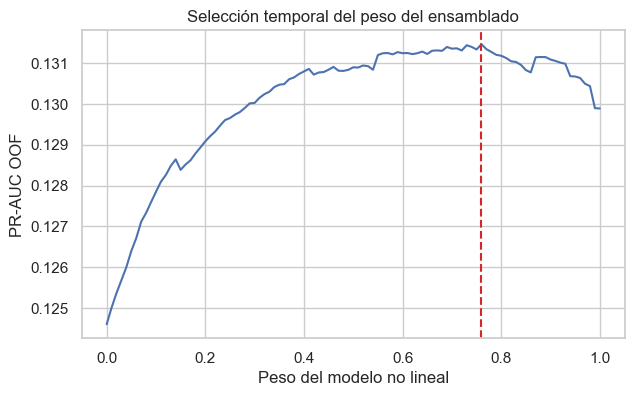

In [8]:
nonlinear_names = [rbf_svm_name, best_rf_name, best_hgb_name, best_xgb_name]
best_nonlinear_name = (
    selected_family_summary.loc[selected_family_summary.modelo.isin(nonlinear_names)]
    .sort_values('pr_auc_media', ascending=False).iloc[0].modelo
)
best_nonlinear_model = selected_models[best_nonlinear_name]
logistic_oof = selected_oof['Logística avanzada']
best_nonlinear_oof = selected_oof[best_nonlinear_name]

oof_mask = np.isfinite(logistic_oof) & np.isfinite(best_nonlinear_oof)
nonlinear_weight, blend_search = optimize_blend_weight(
    y_development.to_numpy()[oof_mask],
    best_nonlinear_oof[oof_mask], logistic_oof[oof_mask],
)
print(f'Modelo no lineal para el blend: {best_nonlinear_name}')
print(f'Peso no lineal aprendido: {nonlinear_weight:.2f}')
print(f'Peso logístico aprendido: {1 - nonlinear_weight:.2f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(blend_search.first_weight, blend_search.pr_auc)
ax.axvline(nonlinear_weight, color='tab:red', linestyle='--')
ax.set(title='Selección temporal del peso del ensamblado',
       xlabel='Peso del modelo no lineal', ylabel='PR-AUC OOF')
plt.show()

## 5. Validación externa en 2024

Cerradas las configuraciones y el peso del blend, los modelos se reentrenan con todo 2019–2023 y se comparan en 2024. PR-AUC es la métrica principal; ROC-AUC, Brier y tiempos son complementarios. Las métricas con umbral 0,5 se muestran solo para diagnosticar la escala probabilística.

In [9]:
fitted_models = {}
validation_probabilities = {}
fit_times = {}

model_definitions = {
    'Dummy': DummyClassifier(strategy='prior'),
    'Logística básica': basic_logistic,
    **selected_models,
}
for name, model in model_definitions.items():
    fitted = clone(model)
    start = time.perf_counter()
    fitted.fit(X_development, y_development)
    fit_times[name] = time.perf_counter() - start
    validation_probabilities[name] = fitted.predict_proba(X_validation)[:, 1]
    fitted_models[name] = fitted
    print(f'Ajustado {name} en {fit_times[name]:.1f} s')

validation_probabilities['Blend temporal'] = (
    nonlinear_weight * validation_probabilities[best_nonlinear_name]
    + (1 - nonlinear_weight) * validation_probabilities['Logística avanzada']
)
fit_times['Blend temporal'] = fit_times[best_nonlinear_name] + fit_times['Logística avanzada']

validation_results = pd.DataFrame({
    name: {**binary_classification_metrics(y_validation, probabilities),
           'fit_time_s': fit_times[name]}
    for name, probabilities in validation_probabilities.items()
}).T.sort_values('pr_auc', ascending=False)
display(validation_results.round(4))

Ajustado Dummy en 0.0 s
Ajustado Logística básica en 2.9 s
Ajustado Logística avanzada en 4.6 s


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3, 4, 8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Ajustado SVM_C01_peso5 en 28.5 s
Ajustado SVC_RBF_C1 en 655.9 s
Ajustado RF_C_peso10 en 34.7 s
Ajustado HGB_B en 3.0 s
Ajustado XGB_C_peso10 en 5.4 s


,pr_auc,roc_auc,brier,precision,recall,f1,f2,predicted_positives,fit_time_s
XGB_C_peso10,0.1553,0.9190,0.0261,0.1717,0.3501,0.2304,0.2899,1217.0,5.3993
HGB_B,0.1475,0.9177,0.0110,0.4000,0.0034,0.0066,0.0042,5.0,3.0134
RF_C_peso10,0.1445,0.9155,0.0232,0.1828,0.2312,0.2041,0.2195,755.0,34.7371
Blend temporal,0.1445,0.9161,0.0180,0.2391,0.1189,0.1588,0.1322,297.0,39.3229
Logística avanzada,0.1422,0.9151,0.0110,0.5000,0.0034,0.0067,0.0042,4.0,4.5858
SVM_C01_peso5,0.1378,0.9146,0.0111,0.5000,0.0017,0.0033,0.0021,2.0,28.5421
Logística básica,0.1088,0.9082,0.0115,0.1875,0.0101,0.0191,0.0124,32.0,2.9463
SVC_RBF_C1,0.0784,0.8492,0.0117,0.2000,0.0017,0.0033,0.0021,5.0,655.8819
Dummy,0.0121,0.5000,0.0120,0.0000,0.0000,0.0000,0.0000,0.0,0.0065


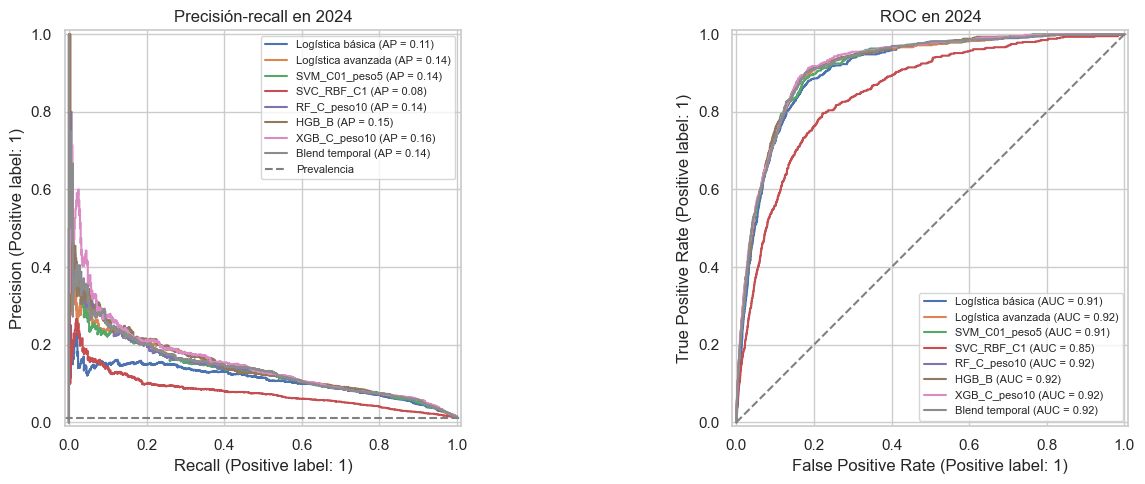

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
comparison_names = [name for name in validation_probabilities if name != 'Dummy']
for name in comparison_names:
    PrecisionRecallDisplay.from_predictions(
        y_validation, validation_probabilities[name], name=name, ax=axes[0]
    )
    RocCurveDisplay.from_predictions(
        y_validation, validation_probabilities[name], name=name, ax=axes[1]
    )
axes[0].axhline(y_validation.mean(), color='grey', linestyle='--', label='Prevalencia')
axes[0].set_title('Precisión-recall en 2024')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--')
axes[1].set_title('ROC en 2024')
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

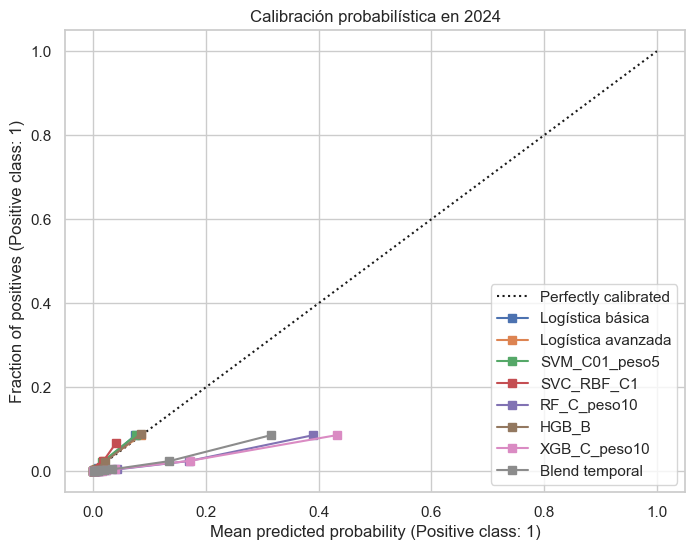

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
for name in comparison_names:
    CalibrationDisplay.from_predictions(
        y_validation, validation_probabilities[name], n_bins=10,
        strategy='quantile', name=name, ax=ax
    )
ax.set_title('Calibración probabilística en 2024')
plt.show()

## 6. Incertidumbre de la mejora

Una diferencia puntual de PR-AUC puede deberse al muestreo. Se calcula un *bootstrap* emparejado y estratificado: en cada réplica se remuestrean positivos y negativos, y ambos modelos se evalúan sobre exactamente la misma muestra. Si el intervalo del 95 % para `modelo - logística` incluye cero, no existe evidencia clara de mejora.

In [12]:
bootstrap_rows = []
for name in comparison_names:
    if name == 'Logística avanzada':
        continue
    interval = paired_bootstrap_pr_auc_difference(
        y_validation,
        validation_probabilities[name],
        validation_probabilities['Logística avanzada'],
        n_resamples=500,
        random_state=RANDOM_STATE,
    )
    bootstrap_rows.append({'modelo': name, **interval})
bootstrap_results = pd.DataFrame(bootstrap_rows).sort_values('difference', ascending=False)
display(bootstrap_results.round(4))

,modelo,difference,lower,upper
5,XGB_C_peso10,0.0131,0.0047,0.0256
4,HGB_B,0.0054,-0.0068,0.0188
3,RF_C_peso10,0.0023,-0.0102,0.0160
6,Blend temporal,0.0023,-0.0071,0.0138
1,SVM_C01_peso5,-0.0043,-0.0121,0.0044
0,Logística básica,-0.0334,-0.0490,-0.0198
2,SVC_RBF_C1,-0.0638,-0.0807,-0.0475


## 7. Selección del modelo y del umbral operativo

Se identifica el mejor PR-AUC en 2024, pero solo se acepta un modelo más complejo si el límite inferior de su intervalo *bootstrap* frente a la logística avanzada es positivo. Si el intervalo incluye cero, se aplica parsimonia. Después se elige el umbral de mayor precisión que conserva al menos un 75 % de recall.

In [13]:
selectable_names = [name for name in validation_results.index if name != 'Dummy']
best_by_pr_auc = validation_results.loc[selectable_names, 'pr_auc'].idxmax()
if best_by_pr_auc == 'Logística avanzada':
    selected_model_name = best_by_pr_auc
    selection_reason = 'La logística avanzada obtiene la mayor PR-AUC.'
else:
    lower_bound = bootstrap_results.loc[
        bootstrap_results.modelo.eq(best_by_pr_auc), 'lower'
    ].iloc[0]
    if lower_bound > 0:
        selected_model_name = best_by_pr_auc
        selection_reason = 'La mejora frente a la logística es positiva en todo el IC 95 %.'
    else:
        selected_model_name = 'Logística avanzada'
        selection_reason = (
            f'{best_by_pr_auc} gana puntualmente, pero su IC 95 % incluye cero; '
            'se aplica el principio de parsimonia.'
        )
selected_probabilities = validation_probabilities[selected_model_name]
selected_threshold = select_threshold_for_recall(
    y_validation, selected_probabilities, minimum_recall=0.75
)

threshold_results = pd.DataFrame({
    'Umbral 0,5': binary_classification_metrics(y_validation, selected_probabilities, 0.5),
    'Umbral operativo': binary_classification_metrics(
        y_validation, selected_probabilities, selected_threshold
    ),
}).T
print(f'Modelo seleccionado: {selected_model_name}')
print(f'Criterio: {selection_reason}')
print(f'Umbral operativo provisional: {selected_threshold:.5f}')
display(threshold_results.round(4))

Modelo seleccionado: XGB_C_peso10
Criterio: La mejora frente a la logística es positiva en todo el IC 95 %.
Umbral operativo provisional: 0.25104


,pr_auc,roc_auc,brier,precision,recall,f1,f2,predicted_positives
"Umbral 0,5",0.1553,0.919,0.0261,0.1717,0.3501,0.2304,0.2899,1217.0
Umbral operativo,0.1553,0.919,0.0261,0.0800,0.7521,0.1446,0.2806,5614.0


## 8. Interpretabilidad por permutación

Para evitar el sesgo de las importancias internas de los árboles, se mide cuánto cae PR-AUC al permutar una variable original. Se usa una muestra estratificada de 20.000 observaciones de 2024 para mantener un coste razonable. La interpretación es predictiva, no causal.

Si ganara el blend, se interpreta además el mejor modelo individual, ya que una media de probabilidades no tiene una única estructura interna.

,variable,caida_pr_auc,desviacion
23,usuario_vulnerable,0.1233,0.0054
8,contexto_persona_accidente,0.0603,0.0023
21,edad_aproximada,0.0342,0.0067
2,estado_meteorologico,0.0201,0.0119
7,grupo_vehiculo,0.0134,0.0039
3,tipo_vehiculo,0.0129,0.0034
1,tipo_accidente,0.0124,0.0070
4,tipo_persona,0.0121,0.0027
6,sexo,0.0110,0.0046
5,rango_edad,0.0098,0.0044


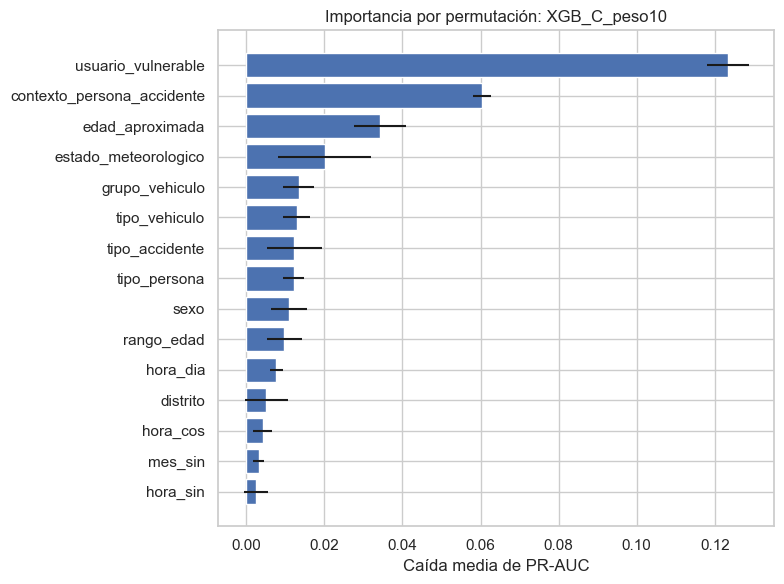

In [14]:
standalone_names = [
    'Logística avanzada', best_svm_name, rbf_svm_name,
    best_rf_name, best_hgb_name, best_xgb_name,
]
best_standalone_name = validation_results.loc[standalone_names, 'pr_auc'].idxmax()
interpretation_model = fitted_models[best_standalone_name]

sample_fraction = min(1.0, 20_000 / len(validation))
interpretation_sample = (
    validation.groupby(target, group_keys=False)
    .sample(frac=sample_fraction, random_state=RANDOM_STATE)
    .sample(frac=1, random_state=RANDOM_STATE)
)

permutation = permutation_importance(
    interpretation_model,
    interpretation_sample[all_features], interpretation_sample[target],
    scoring='average_precision', n_repeats=5, n_jobs=-1,
    random_state=RANDOM_STATE,
)
importance = pd.DataFrame({
    'variable': all_features,
    'caida_pr_auc': permutation.importances_mean,
    'desviacion': permutation.importances_std,
}).sort_values('caida_pr_auc', ascending=False)
display(importance.head(15).round(4))

fig, ax = plt.subplots(figsize=(8, 6))
plot_data = importance.head(15).sort_values('caida_pr_auc')
ax.barh(plot_data.variable, plot_data.caida_pr_auc, xerr=plot_data.desviacion)
ax.set(title=f'Importancia por permutación: {best_standalone_name}',
       xlabel='Caída media de PR-AUC', ylabel='')
plt.tight_layout()
plt.show()

## 9. Auditoría por sexo y edad

Vamos a revisar la variables de sexoy edad. No se redefinen los umbrales por grupo, eso ocultaría diferencias del modelo.

In [15]:
def subgroup_audit(group_column, minimum_positives=20):
    rows = []
    group_values = validation[group_column].fillna('No consta')
    for group_value in sorted(group_values.unique().astype(str)):
        mask = group_values.astype(str).eq(group_value).to_numpy()
        positives = int(y_validation.to_numpy()[mask].sum())
        if positives < minimum_positives:
            continue
        metrics = binary_classification_metrics(
            y_validation.to_numpy()[mask], selected_probabilities[mask], selected_threshold
        )
        rows.append({
            'grupo': group_value, 'n': int(mask.sum()), 'positivos': positives,
            'prevalencia': float(y_validation.to_numpy()[mask].mean()), **metrics,
        })
    return pd.DataFrame(rows).sort_values('recall')

audit_sex = subgroup_audit('sexo')
audit_age = subgroup_audit('rango_edad')
display(audit_sex.round(4))
display(audit_age.round(4))

,grupo,n,positivos,prevalencia,pr_auc,roc_auc,brier,precision,recall,f1,f2,predicted_positives
1,Mujer,14295,175,0.0122,0.1795,0.9249,0.0249,0.0941,0.7257,0.1667,0.3099,1349
0,Hombre,29812,422,0.0142,0.1465,0.9019,0.0313,0.0755,0.7630,0.1374,0.2705,4265


,grupo,n,positivos,prevalencia,pr_auc,roc_auc,brier,precision,recall,f1,f2,predicted_positives
1,De 25 a 29 años,4817,64,0.0133,0.1139,0.8639,0.0287,0.0590,0.5625,0.1068,0.2079,610
0,De 21 a 24 años,3277,35,0.0107,0.0892,0.9103,0.0257,0.0599,0.6286,0.1095,0.2170,367
6,De 50 a 54 años,4539,65,0.0143,0.1775,0.9082,0.0280,0.0803,0.6769,0.1436,0.2723,548
2,De 30 a 34 años,4828,58,0.0120,0.1039,0.8938,0.0282,0.0620,0.7069,0.1140,0.2296,661
8,De 60 a 64 años,2437,38,0.0156,0.2873,0.9007,0.0326,0.1000,0.7632,0.1768,0.3281,290
10,De 70 a 74 años,728,22,0.0302,0.3555,0.9256,0.0456,0.1848,0.7727,0.2982,0.4722,92
5,De 45 a 49 años,5002,50,0.0100,0.1404,0.8867,0.0253,0.0664,0.7800,0.1224,0.2478,587
4,De 40 a 44 años,4697,51,0.0109,0.1162,0.9064,0.0217,0.0795,0.7843,0.1444,0.2829,503
7,De 55 a 59 años,3489,43,0.0123,0.1178,0.9331,0.0286,0.0831,0.8140,0.1509,0.2951,421
11,Más de 74 años,1207,53,0.0439,0.2869,0.8996,0.0775,0.1753,0.8302,0.2895,0.4752,251


### Elimicación de la variable `sexo`

Como comprobación adicional, se reentrena el mejor modelo individual sin `sexo` para ver si merece la pena mantenerlo

In [23]:
if best_standalone_name == 'Logística avanzada':
    model_without_sex = make_logistic(include_sex=False)
elif best_standalone_name == best_svm_name:
    model_without_sex = make_linear_svm(svm_configurations[best_svm_name], include_sex=False)
elif best_standalone_name == rbf_svm_name:
    model_without_sex = make_rbf_svm(include_sex=False)
elif best_standalone_name == best_rf_name:
    model_without_sex = make_random_forest(rf_configurations[best_rf_name], include_sex=False)
elif best_standalone_name == best_hgb_name:
    model_without_sex = make_hist_gradient_boosting(
        hgb_configurations[best_hgb_name], include_sex=False
    )
else:
    model_without_sex = make_xgboost(xgb_configurations[best_xgb_name], include_sex=False)

model_without_sex.fit(X_development, y_development)
probability_without_sex = model_without_sex.predict_proba(X_validation)[:, 1]
ablation_threshold = select_threshold_for_recall(
    y_validation, validation_probabilities[best_standalone_name], 0.75
)
ablation = pd.DataFrame({
    'Con sexo': binary_classification_metrics(
        y_validation, validation_probabilities[best_standalone_name], ablation_threshold
    ),
    'Sin sexo': binary_classification_metrics(
        y_validation, probability_without_sex, ablation_threshold
    ),
}).T
print(f"Mejor modelo: {best_standalone_name}")
display(ablation.round(4))



Mejor modelo: XGB_C_peso10


,pr_auc,roc_auc,brier,precision,recall,f1,f2,predicted_positives
Con sexo,0.1553,0.919,0.0261,0.0800,0.7521,0.1446,0.2806,5614.0
Sin sexo,0.1520,0.918,0.0261,0.0811,0.7588,0.1466,0.2841,5584.0


,pr_auc,roc_auc,brier,precision,recall,f1,f2,predicted_positives
Con sexo,0.155292,0.919013,0.026144,0.079979,0.752094,0.144582,0.280555,5614.0
Sin sexo,0.151970,0.918043,0.026117,0.081125,0.758794,0.146578,0.284119,5584.0


El efecto de la variable sexo es mínimo por lo que para evitar posibles problemas de discriminación es mejor eliminarla

In [26]:
probabilities_without_sex = model_without_sex.predict_proba(X_validation)[:, 1]

threshold_without_sex = select_threshold_for_recall(
    y_validation,
    probabilities_without_sex,
    minimum_recall=0.75,)

print(f'Umbral del modelo sin sexo: {threshold_without_sex:.10f}')

Umbral del modelo sin sexo: 0.2524931729


## 10. Decisión y siguiente fase

Finalmente se selecciona un XGBoost sin la variable sexo.

En el próximo notebook se congelarán variables, hiperparámetros y umbral. Se reentrenará con 2019–2024 y se hará **una única evaluación final en 2025**. Finalmente se productivizará el modelo. Para la siguiente fase serán necesarios los parámetros del modelo seleccionado.

In [22]:

model_parameters = model_without_sex.named_steps['model'].get_params()


parameter_names = [
    'n_estimators',
    'learning_rate',
    'max_depth',
    'min_child_weight',
    'subsample',
    'colsample_bytree',
    'reg_alpha',
    'reg_lambda',
    'scale_pos_weight',
]

selected_parameters = {
    name: model_without_sex.named_steps['model'].get_params()[name]
    for name in parameter_names
}

selected_parameters


{'n_estimators': 300,
 'learning_rate': 0.05,
 'max_depth': 4,
 'min_child_weight': 10,
 'subsample': 0.8,
 'colsample_bytree': 0.8,
 'reg_alpha': 0.0,
 'reg_lambda': 5.0,
 'scale_pos_weight': 10}